# 3. Análisis de Causa Raíz con SHAP
## 3.1 Explicaciones Locales con SHAP

SHAP values shape: 10000 muestras x 13 features


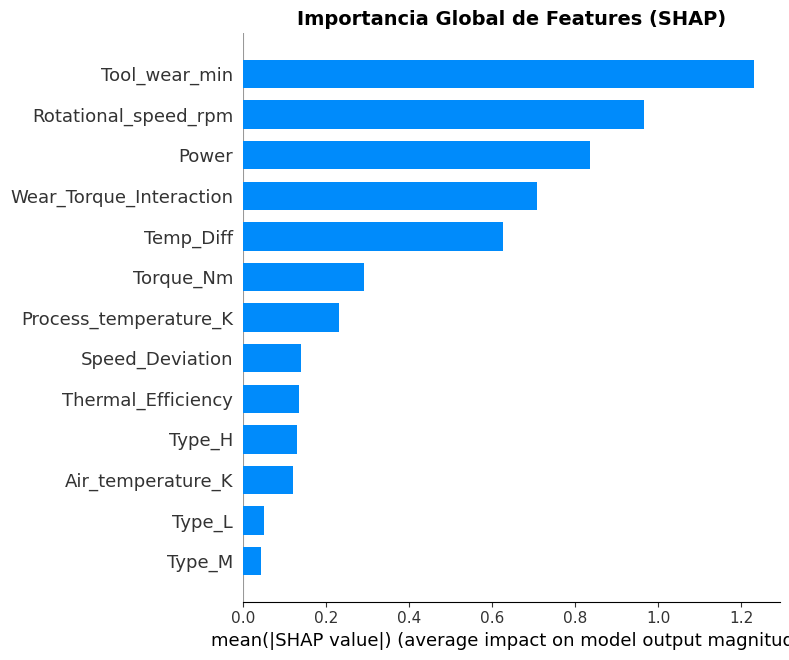

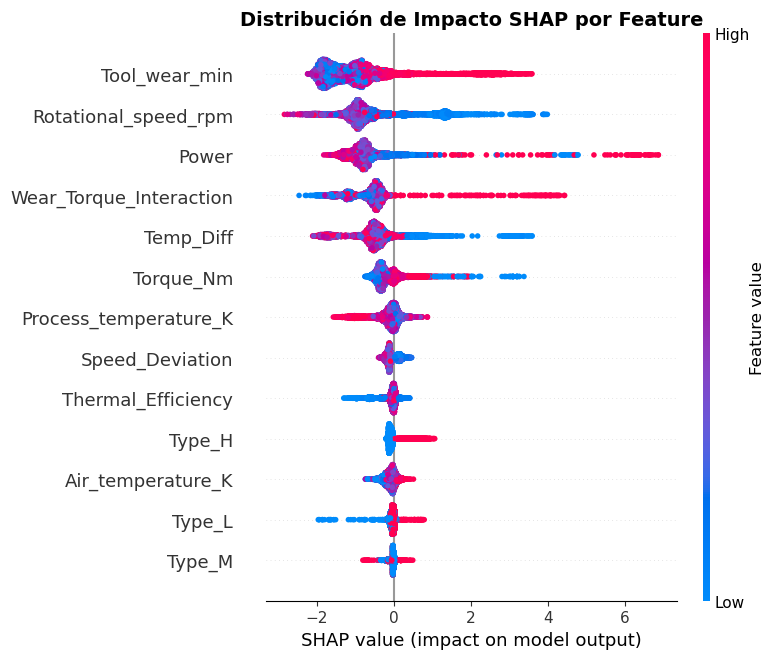

In [4]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Cargar modelo y datos
model = joblib.load('../models/best_model.pkl')
X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_target.csv').values.ravel()
y_modes = pd.read_csv('../data/y_failure_modes.csv')

# Limpiar nombres de características para XGBoost
# XGBoost no permite caracteres como [, ], <, > en los nombres
def clean_feature_names(df):
    """Limpiar los nombres de las características para cumplir con los
    requisitos de XGBoost"""
    df_clean = df.copy()
    df_clean.columns = [col.replace('[', '').replace(']', '').replace('<', '')
                        .replace('>', '').replace(' ', '_').strip() 
                        for col in df_clean.columns]
    return df_clean

X_clean = clean_feature_names(X)

# Extraer el clasificador del pipeline
classifier = model.named_steps['classifier']

# Crear explainer SHAP usando TreeExplainer para XGBoost/Random Forest
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_clean)

print(f"SHAP values shape: {len(shap_values)} muestras x {X.shape[1]} features")

# Resumen global SHAP
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_clean, plot_type='bar', show=False)
plt.title('Importancia Global de Features (SHAP)', fontsize=14,
            fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_global_importance.png', dpi=300,
            bbox_inches='tight')
plt.show()

# Resumen con distribución de impactos
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_clean, show=False)
plt.title('Distribución de Impacto SHAP por Feature', fontsize=14,
            fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_summary_plot.png', dpi=300,
            bbox_inches='tight')
plt.show()

## 3.2 Algoritmo de Diagnóstico de Causa Raíz


🔍 DIAGNÓSTICO PARA MUESTRA 50:
   Causa Principal: PWF - Fallo de Potencia (Confianza: 0.90)
   Evidencia: ['Alta Potencia (-4.59) contribuye al fallo', 'Baja diferencia de temperatura (0.20K)']
   Modos Reales: ['PWF']


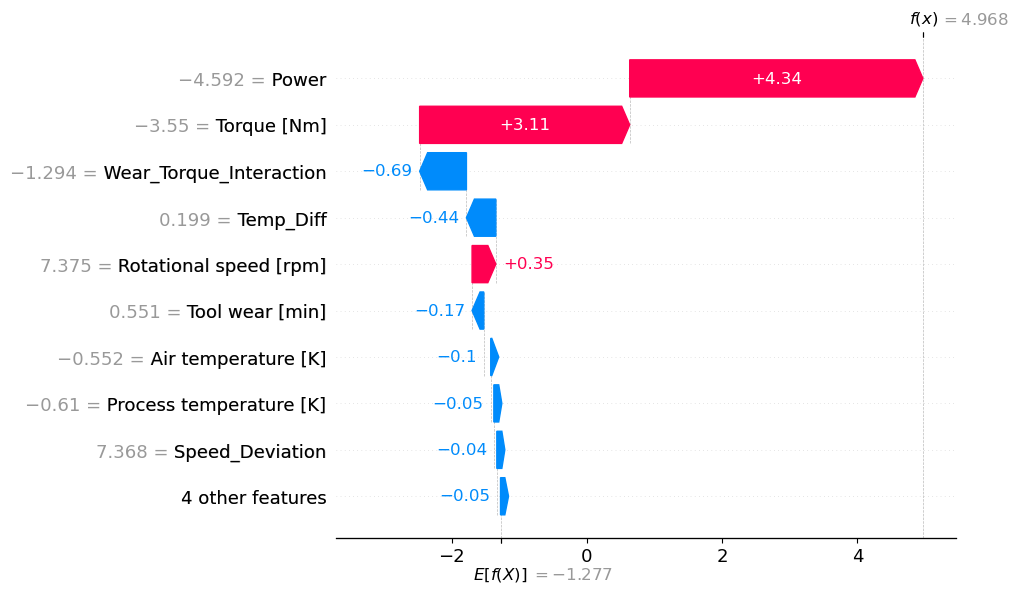

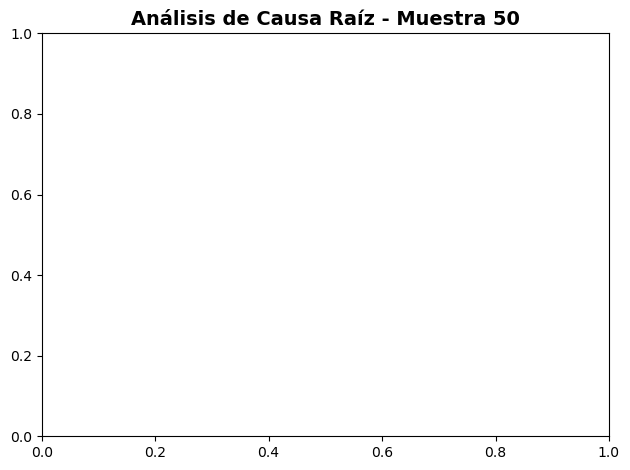

In [15]:
# Función para diagnosticar causa raíz basada en SHAP
def diagnose_failure(shap_values_sample, sample_features, y_modes_samples=None,
                    threshold=0.15):
    """
    Diagnostica la causa raíz de una falla usando SHAP y conocimiento del dominio.

    Args:
        shap_values_sample: SHAP values para una muestra específica
        sample_features: DataFrame con los valores de features de la muestra
        y_modes_sample: Valores reales de modos de fallo (opcional)
        threshold: Umbral mínimo de contribución para considerar un feature

    Returns:
        dict: Diagnóstico con causa más probable y evidencia
    """
    # Crear DataFrame con contribuciones SHAP
    shap_df = pd.DataFrame({
        'feature': X.columns,
        'shap_value': shap_values_sample.flatten(),
        'value': sample_features.flatten()
    })

    # Ordenar por contribución absoluta
    shap_df['abs_shap'] = np.abs(shap_df['shap_value'])
    top_features = shap_df.sort_values('abs_shap', ascending=False).head(5)
    top_features = top_features[top_features['abs_shap'] > threshold]

    # Reglas de diagnóstico basadas en conocimiento del dominio
    diagnosis = {
        'causa_principal': None,
        'evidencia': [],
        'confianza': 0.0,
        'modos_posibles': []
    }

    # Analizar cada top feature
    for _, row in top_features.iterrows():
        feature = row['feature']
        value = row['value']
        shap_val = row['shap_value']

        # Reglas específicas
        if feature == 'Power' and shap_val > 0:
            diagnosis['modos_posibles'].append(('PWF - Fallo de Potencia', 0.9))
            diagnosis['evidencia'].append(f'Alta Potencia ({value:.2f}) contribuye al fallo')
        elif feature == 'Tool wear [min]' and shap_val > 0:
            if value > 200:
                diagnosis['modos_posibles'].append(('TWF - Desgaste de herramienta', 0.85))
                diagnosis['evidencia'].append(f'Desgaste crítico ({value:.0f} min)')
            else:
                diagnosis['modos_posibles'].append(('TWF - Desgaste de herramienta', 0.6))
        elif feature == 'Wear_Torque_Interaction' and shap_val > 0:
            diagnosis['modos_posibles'].append(('OSF - Sobreesfuerzo', 0.8))
            diagnosis['evidencia'].append(f'Interacción desgaste x torque alta ({value:.2f})')
        elif feature == 'Temp_Diff' and shap_val < 0:
            diagnosis['modos_posibles'].append(('HDF - Fallo por Disipación de Calor', 0.75))
            diagnosis['evidencia'].append(f'Baja diferencia de temperatura ({value:.2f}K)')
        elif feature == 'Thermal_Efficiency' and shap_val > 0:
            diagnosis['modos_posibles'].append(('HDF - Fallo por Disipación de Calor', 0.7))
            diagnosis['evidencia'].append(f'Alta eficiencia térmica ({value:.2f}%)')
    
    # Priorizar diagnóstico
    if diagnosis['modos_posibles']:
        # Ordenar por confianza
        diagnosis['modos_posibles'].sort(key=lambda x: x[1], reverse=True)
        diagnosis['causa_principal'], diagnosis['confianza'] = diagnosis['modos_posibles'][0]

    # Si hay fallo real, validar contra ground truth
    if y_modes_sample is not None:
        real_modes = [col for col in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
                        if y_modes_sample[col].values[0] == 1]
        if real_modes:
            diagnosis['modos_reales'] = real_modes
    
    return diagnosis

# Probar en muestras de fallo
fallo_indices = X[y == 1].index
sample_idx = fallo_indices[0]   # Tomar primer fallo

shap_sample = shap_values[sample_idx]
x_sample = X.iloc[sample_idx:sample_idx+1]
y_modes_sample = y_modes.iloc[sample_idx:sample_idx+1]

diagnostico = diagnose_failure(shap_sample, x_sample.values, y_modes_sample)

print(f"\n🔍 DIAGNÓSTICO PARA MUESTRA {sample_idx}:")
print(f"   Causa Principal: {diagnostico['causa_principal']} (Confianza: {diagnostico['confianza']:.2f})")
print(f"   Evidencia: {diagnostico['evidencia']}")
if 'modos_reales' in diagnostico:
    print(f"   Modos Reales: {diagnostico['modos_reales']}")

# Visualizar SHAP para el caso específico
plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap.Explanation(values=shap_sample, 
                                     base_values=explainer.expected_value, 
                                     data=x_sample.values[0], 
                                     feature_names=X.columns))
plt.title(f'Análisis de Causa Raíz - Muestra {sample_idx}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/shap_waterfall_failure_sample.png', dpi=300, bbox_inches='tight')
plt.show()

## 3.3 Validación de Diagnóstico en Batch

In [18]:
# Diagnosticar todos los fallos
diagnosticos = []
indices_fallos = X[y==1].index

for idx in indices_fallos[:50]:
    shap_sample = shap_values[idx]
    x_sample = X.iloc[idx:idx+1]
    y_modes_sample = y_modes.iloc[idx:idx+1]

    diag = diagnose_failure(shap_sample, x_sample.values, y_modes_sample, threshold=0.05)
    diag['indice'] = idx
    diagnosticos.append(diag)

# Crear dataframe de resultados
df_diagnosticos = pd.DataFrame([{
    'indice': d['indice'],
    'causa_principal': d['causa_principal'],
    'confianza': d['confianza'],
    'modos_reales': d.get('modos_reales', [])
} for d in diagnosticos])

# Calcular precisión del diagnóstico
def match_diagnosis(row):
    if not row['modos_reales']:
        return 'Sin fallo real'
    # Verificar si la causa principal coincide con algún modo real
    for modo in row['modos_reales']:
        if row['causa_principal'] and modo in row['causa_principal']:
            return 'Correcto'
    return 'Incorrecto'

df_diagnosticos['match'] = df_diagnosticos.apply(match_diagnosis, axis=1)

print("\nEstadísticas de Diagnóstico:")
print(df_diagnosticos['match'].value_counts(normalize=True))
print(f"\nPrecisión del diagnóstico: {df_diagnosticos[df_diagnosticos['match'] == 'Correcto'].shape[0] / len(df_diagnosticos):.2%}")


Estadísticas de Diagnóstico:
match
Correcto          0.90
Incorrecto        0.08
Sin fallo real    0.02
Name: proportion, dtype: float64

Precisión del diagnóstico: 90.00%
